# Perform single-cell quality control

In this notebook, we perform single-cell quality control using coSMicQC.
To filter the single-cells, the default method is z-score to find outliers using the values from only one feature at a time. 
We use features from the AreaShape and Intensity modules to assess the quality of the segmented single-cells:

### Assessing poor nuclei segmentation

We use the following features either in combination or alone when finding technical segmentation errors.
To be specific, we use:

| Measurement(s)           | Target                                                           | Notes                                                                                                                                                        |
|--------------------------|------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Nuclei Soldity + Mass Displacement in DAPI channel | Mis-segmented nuclei from debris, artifacts or over-segmented clusters | We use these two features in combination where one finds the indented/non-smooth nuclei segmentations and the finds segmentations where the centeroid based on intensity is highly shifted (meaning multiple nuclei or segmented artifacts).                                           |
| Nuclei Area      | Under-segmented nuclei   | We use this by itself to find abnormally small nuclei which related to under-segmentation from the algorithm.                                                  |


## Import libraries

In [1]:
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from cytodataframe import CytoDataFrame
from cosmicqc import find_outliers

## Set paths and variables

In [2]:
# Directory with data
data_dir = pathlib.Path("./data/converted_profiles/")

# Directory to save cleaned data
qc_dir = pathlib.Path("./data/single_cell_qc/")
qc_dir.mkdir(exist_ok=True)

# Directory to save qc figures
qc_fig_dir = pathlib.Path("./qc_figures")
qc_fig_dir.mkdir(exist_ok=True)

# Create an empty dictionary to store data frames for each plate
all_qc_data_frames = {}

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Position",
    "Image_Metadata_Best_Z",
    "Nuclei_Location_Center_X",
    "Nuclei_Location_Center_Y",
    "Nuclei_AreaShape_BoundingBoxMaximum_X",
    "Nuclei_AreaShape_BoundingBoxMaximum_Y",
    "Nuclei_AreaShape_BoundingBoxMinimum_X",
    "Nuclei_AreaShape_BoundingBoxMinimum_Y",
    "Image_PathName_DAPI",
    "Image_FileName_DAPI",
]

## Concat all plates together to assess quality control

In [3]:
# Only process the files that are in the plate names list
plate_path = pathlib.Path(f"{data_dir}/u2os_per_nuclei.parquet")

# Read the parquet file into a DataFrame
qc_df = pd.read_parquet(plate_path)

print(qc_df.shape)
qc_df.head()

(9142, 587)


,Metadata_ImageNumber,Image_Metadata_Plate,Image_Metadata_Position,Image_Metadata_Best_Z,Image_Metadata_Well,Image_Count_Nuclei,Image_FileName_DAPI,Image_PathName_DAPI,Nuclei_AreaShape_Area,Nuclei_AreaShape_BoundingBoxArea,...,Nuclei_Texture_Variance_DAPI_3_02_256,Nuclei_Texture_Variance_DAPI_3_03_256,Nuclei_Texture_Variance_SON_3_00_256,Nuclei_Texture_Variance_SON_3_01_256,Nuclei_Texture_Variance_SON_3_02_256,Nuclei_Texture_Variance_SON_3_03_256,Nuclei_Texture_Variance_SRRM2_3_00_256,Nuclei_Texture_Variance_SRRM2_3_01_256,Nuclei_Texture_Variance_SRRM2_3_02_256,Nuclei_Texture_Variance_SRRM2_3_03_256
0,56,Rep1,pos11,bestZ08,well4,91,Rep1_well4_pos11_ch01_bestZ08_illumcorrect.tiff,/media/18tbdrive/1.Github_Repositories/nuclear...,15989.0,24752.0,...,1.815237,1.812969,0.035727,0.035628,0.035867,0.035409,0.159730,0.160951,0.161322,0.161479
1,76,Rep2,pos01,bestZ08,well2,106,Rep2_well2_pos01_ch01_bestZ08_illumcorrect.tiff,/media/18tbdrive/1.Github_Repositories/nuclear...,13313.0,17812.0,...,7.203302,6.883129,0.232751,0.233829,0.232487,0.234566,1.126808,1.126018,1.127103,1.124656
2,37,Rep1,pos07,bestZ08,well3,90,Rep1_well3_pos07_ch01_bestZ08_illumcorrect.tiff,/media/18tbdrive/1.Github_Repositories/nuclear...,21825.0,29704.0,...,1.839041,1.813573,0.128979,0.129911,0.129453,0.129882,0.601559,0.604225,0.602257,0.603529
3,38,Rep1,pos08,bestZ08,well3,52,Rep1_well3_pos08_ch01_bestZ08_illumcorrect.tiff,/media/18tbdrive/1.Github_Repositories/nuclear...,19757.0,25283.0,...,5.735218,5.440867,0.159656,0.160179,0.158928,0.159920,0.717333,0.718949,0.716246,0.718229
4,17,Rep1,pos02,bestZ08,well2,24,Rep1_well2_pos02_ch01_bestZ08_illumcorrect.tiff,/media/18tbdrive/1.Github_Repositories/nuclear...,17882.0,22962.0,...,3.132477,3.068710,0.166991,0.168187,0.167305,0.168270,0.713079,0.714231,0.713698,0.714156


## Evaluate the distributions of the features across plates to determine best features to use for QC

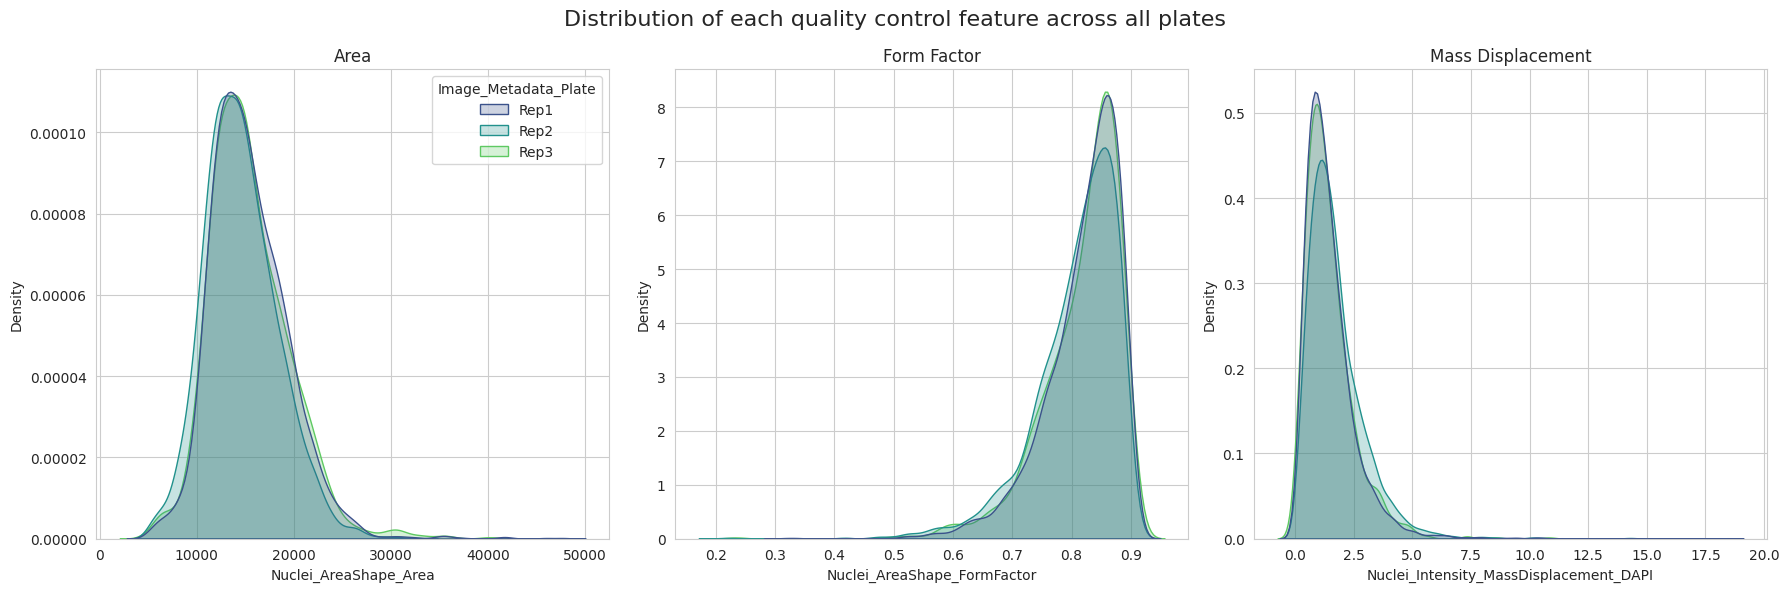

In [4]:
# Set the style
sns.set_style("whitegrid")

# Create subplots with 2 rows and 2 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # first is width and second is height

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Create kdeplot for Nuclei_AreaShape_Area
sns.kdeplot(
    data=qc_df,
    x="Nuclei_AreaShape_Area",
    hue="Image_Metadata_Plate",
    palette="viridis",
    fill=True,
    common_norm=False,
    ax=axes[0],  # Set the first subplot
)
axes[0].set_title("Area")

# Create kdeplot for FormFactor
sns.kdeplot(
    data=qc_df,
    x="Nuclei_AreaShape_FormFactor",
    hue="Image_Metadata_Plate",
    palette="viridis",
    fill=True,
    common_norm=False,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Form Factor")

# Create kdeplot for MassDisplacement
sns.kdeplot(
    data=qc_df,
    x="Nuclei_Intensity_MassDisplacement_DAPI",
    hue="Image_Metadata_Plate",
    palette="viridis",
    fill=True,
    common_norm=False,
    ax=axes[2],
    legend=False,
)
axes[2].set_title("Mass Displacement")

plt.suptitle(
    "Distribution of each quality control feature across all plates",
    fontsize=16,
)
plt.tight_layout(rect=[0, 0, 1.0, 1.0])  # Adjust subplot layout

# Save figure
plt.savefig(pathlib.Path(f"{qc_fig_dir}/QC_features_dist_plot.png"), dpi=500)

plt.show()

## Use Nuclei Solidity and Mass Displacement to detect improperly segmented nuclei (debris, artifacts, over-segmentation)

In [5]:
outline_to_orig_mapping = {
    rf"{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Position']}_ch01_{record['Image_Metadata_Best_Z']}_illumcorrect_MaskNuclei.tiff": rf"{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Position']}_ch\d+_{record['Image_Metadata_Best_Z']}_illumcorrect.tiff"
    for record in qc_df[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Position",
            "Image_Metadata_Best_Z",
        ]
    ].to_dict(orient="records")
}

next(iter(outline_to_orig_mapping.items()))

('Rep1_well4_pos11_ch01_bestZ08_illumcorrect_MaskNuclei.tiff',
 'Rep1_well4_pos11_ch\\d+_bestZ08_illumcorrect.tiff')

Number of outliers: 158 (1.73%)
Outliers Range:
Nuclei_AreaShape_Solidity Min: 0.5251993380472394
Nuclei_AreaShape_Solidity Max: 0.9361149110807113
Nuclei_Intensity_MassDisplacement_DAPI Min: 2.7627217186378554
Nuclei_Intensity_MassDisplacement_DAPI Max: 14.442979663499278


,8987,1387,3349,5149,6043
Nuclei_AreaShape_Solidity,0.525199,0.559398,0.602618,0.751263,0.798952
Nuclei_Intensity_MassDisplacement_DAPI,6.623196,10.54998,10.749972,8.842697,7.862984
Image_FileName_DAPI,,,,,

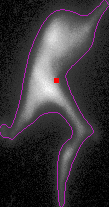
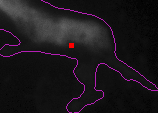
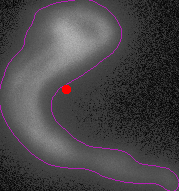
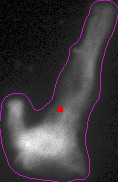
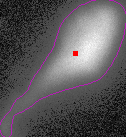

In [6]:
# find abnormally large nuclei based on area
feature_thresholds = {
    "Nuclei_AreaShape_Solidity": -2,
    "Nuclei_Intensity_MassDisplacement_DAPI": 1,
}

missegmented_nuclei_outliers = find_outliers(
    df=qc_df, metadata_columns=metadata_columns, feature_thresholds=feature_thresholds
)

# Convert to CytoDataFrame for outline viewing
missegmented_nuclei_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(missegmented_nuclei_outliers),
    data_context_dir="../1.illumination_correction/IC_corrected_images",
    data_mask_context_dir="../2.cp_analysis/analysis_output/",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 5,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Nuclei_AreaShape_Solidity",
        "Nuclei_Intensity_MassDisplacement_DAPI",
        "Image_FileName_DAPI",
    ]
]

missegmented_nuclei_outliers_cdf.sort_values(
    by="Nuclei_AreaShape_Solidity", ascending=True
).head().T

Number of outliers: 116 (1.27%)
Outliers Range:
Nuclei_AreaShape_Area Min: 5040.0
Nuclei_AreaShape_Area Max: 7073.0


,2482,2515,8064,3858,5801
Nuclei_AreaShape_Area,5040.0,5048.0,5062.0,5068.0,5072.0
Image_FileName_DAPI,,,,,

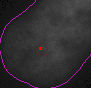
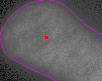
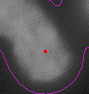
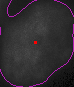
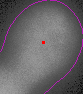

In [7]:
# find abnormally small nuclei based on area
feature_thresholds = {
    "Nuclei_AreaShape_Area": -2,
}

small_nuclei_outliers = find_outliers(
    df=qc_df, metadata_columns=metadata_columns, feature_thresholds=feature_thresholds
)

# Convert to CytoDataFrame for outline viewing
small_nuclei_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(small_nuclei_outliers),
    data_context_dir="../1.illumination_correction/IC_corrected_images",
    data_mask_context_dir="../2.cp_analysis/analysis_output/",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 5,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Nuclei_AreaShape_Area",
        "Image_FileName_DAPI",
    ]
]

small_nuclei_outliers_cdf.sort_values(
    by="Nuclei_AreaShape_Area", ascending=True
).head().T

## Output file with metadata and columns indicating if the cell failed QC or not

In [8]:
# Set metadata columns to include in output data frame
output_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Position",
    "Image_Metadata_Best_Z",
    "Nuclei_Location_Center_X",
    "Nuclei_Location_Center_Y",
]

# Make a copy of qc_df to avoid modifying the original DataFrame
qc_df_copy = qc_df.copy()

# Add columns to indicate QC failure for missegmented and small nuclei
qc_df_copy["Metadata_cqc_failed_missegmented_nuclei"] = qc_df_copy.index.isin(
    missegmented_nuclei_outliers.index
)
qc_df_copy["Metadata_cqc_failed_small_nuclei"] = qc_df_copy.index.isin(
    small_nuclei_outliers.index
)

# Select only metadata columns and the new QC columns
qc_output_df = qc_df_copy[
    output_metadata_columns
    + [
        "Metadata_cqc_failed_missegmented_nuclei",
        "Metadata_cqc_failed_small_nuclei",
    ]
]

# Save the resulting DataFrame to a parquet file
qc_output_df.to_parquet(qc_dir / "qc.parquet", index=False)

# Show the first few rows of the output DataFrame
print(
    "Number of nuclei that failed QC in either condition:",
    qc_output_df[
        ["Metadata_cqc_failed_missegmented_nuclei", "Metadata_cqc_failed_small_nuclei"]
    ]
    .any(axis=1)
    .sum(),
)
print("Shape of the output DataFrame:", qc_output_df.shape)
qc_output_df.head()

Number of nuclei that failed QC in either condition: 268
Shape of the output DataFrame: (9142, 8)


,Image_Metadata_Plate,Image_Metadata_Well,Image_Metadata_Position,Image_Metadata_Best_Z,Nuclei_Location_Center_X,Nuclei_Location_Center_Y,Metadata_cqc_failed_missegmented_nuclei,Metadata_cqc_failed_small_nuclei
0,Rep1,well4,pos11,bestZ08,2606.199387,159.220026,False,False
1,Rep2,well2,pos01,bestZ08,2725.508225,126.918651,False,False
2,Rep1,well3,pos07,bestZ08,2814.986575,210.007743,False,False
3,Rep1,well3,pos08,bestZ08,3454.167029,146.409020,False,False
4,Rep1,well2,pos02,bestZ08,1064.443742,264.632927,False,False
